# Fase 7 — Addestramento PPO preliminare

Questo notebook legge direttamente manifest, report e log della nuova pipeline. Distingue **correttezza tecnica**, **riproducibilità del training**, **stabilità fra seed** e **redditività**: nessuna di queste proprietà implica automaticamente le altre.

Il vecchio esperimento è conservato nelle cartelle `seed_42`, `seed_43`, `seed_44` senza identificativo di esperimento. Le sue cifre erano coerenti con i modelli, ma il confronto dei reward aveva durate diverse e lo scaler era stimato oltre il sottoinsieme PPO. Non viene mescolato ai risultati corretti.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "config.yaml").exists() and (p / "scripts/train_ppo.py").exists())
RUN_ID = "phase7_corrected_20260929"  # Identifica esplicitamente l'esperimento, senza scegliere file legacy.
REPORT_DIR = ROOT / "reports/ppo_prototype" / RUN_ID
manifest = json.loads((REPORT_DIR / "manifest.json").read_text(encoding="utf-8"))
report = json.loads((REPORT_DIR / "summary.json").read_text(encoding="utf-8"))
assert report["run_id"] == manifest["run_id"] == RUN_ID
runs = report["runs"]
primary = [r for r in runs if not r["label"].endswith("_repeat")]
assessment = report["assessment"]
display(Markdown(f"**Esperimento:** `{RUN_ID}` — **creato:** {manifest['created_utc']}"))


**Esperimento:** `phase7_corrected_20260929` — **creato:** 2026-09-29T18:08:45.691943+00:00

## Dati e normalizzazione

Il CSV M1 viene validato e aggregato in M15 nelle fasi precedenti; PPO usa `data/processed/xauusd_m15.parquet`. Le feature sono causali e il warm-up viene rimosso prima dello split cronologico 70/15/15. Il prototipo utilizza il primo 25% del training.

**Media e deviazione standard sono stimate esclusivamente sul sottoinsieme effettivo** e poi applicate alla validation. Il test non è usato. La validation può utilizzare storia precedente per calcolare feature causali; non contribuisce allo scaler. Prezzi e feature hanno lo stesso indice.

Il manifest conserva intervalli, colonne, scaler, configurazione effettiva, hash M15, hash dei sorgenti, commit e stato Git, versioni delle librerie. Per usare un modello occorre conservare anche il manifest presente nella cartella dell'esperimento in `models/prototype`.


In [2]:
data = manifest["data"]
display(pd.DataFrame({"training effettivo": data["train"], "validation": data["validation"]}).T)
display(Markdown(f"**SHA-256 M15:** `{data['m15_sha256']}`"))
normalization = data["normalization"]
if normalization:
    display(pd.DataFrame({"media training": normalization["means"], "deviazione standard": normalization["stds"]}))
assert pd.Timestamp(data["train"]["end"]) < pd.Timestamp(data["validation"]["start"])
assert data["test_used"] is False


,rows,start,end
training effettivo,69759,2004-06-21 18:45:00,2011-07-22 13:00:00
validation,59794,2020-10-23 03:00:00,2023-05-30 11:15:00


**SHA-256 M15:** `eff66b0c2a0d3a0bb3154bf36e48dec0217aee313110050ed3725c0507cd3e10`

,media training,deviazione standard
return_1,0.000022,0.002089
return_4,0.000089,0.004149
return_16,0.000353,0.008201
atr_over_close,0.002236,0.001292
close_ema20_over_atr,0.125084,1.432509
close_ema50_over_atr,0.321259,2.392340
ema20_ema50_over_atr,0.196175,1.299481
candle_body_over_range,0.008562,0.545072
upper_wick_over_range,0.257734,0.216308
lower_wick_over_range,0.267733,0.219743


## Protocollo e criteri di accettazione

PPO usa policy MLP, tre azioni (`0 = short`, `1 = flat`, `2 = long`), costi di execution delle fasi precedenti e partenze casuali nel training. La validation è deterministica.

Il budget nominale può essere superato per completare il rollout. CPU, un thread PyTorch e algoritmi deterministici riducono la variabilità numerica. La ripetizione del primo seed ha lo stesso budget e gli stessi dati delle esecuzioni principali.

I criteri vengono salvati **prima del training**: almeno tre seed distinti; nessuna azione oltre la soglia di degenerazione; uguaglianza dei pesi e risultati nel seed ripetuto; intervallo dei rendimenti medi su finestre e delle quote di azione entro le tolleranze riportate sotto. Le soglie sono criteri ingegneristici dichiarati per il prototipo, non test statistici né una garanzia economica. Tre seed sono una verifica preliminare.


In [3]:
agent = manifest["config"]["agent"]
keys = ["learning_rate", "n_steps", "batch_size", "n_epochs", "gamma", "gae_lambda",
        "ent_coef", "total_timesteps", "train_fraction", "seeds", "device", "torch_threads",
        "comparison_steps", "degeneracy_threshold"]
display(pd.Series({k: agent[k] for k in keys}, name="Configurazione"))
display(pd.Series(assessment["criteria"], name="Tolleranze assolute"))
assert assessment["criteria"] == agent["acceptance"]
display(pd.DataFrame([{"esecuzione": r["label"], "seed": r["seed"],
                       "passi nominali": r["nominal_timesteps"], "passi effettivi": r["actual_timesteps"],
                       "episodi training": r["training"]["episodes"],
                       "caricamento verificato": r["native_reload_verified"]} for r in runs]))


learning_rate                 0.0003
n_steps                         2048
batch_size                       256
n_epochs                          10
gamma                           0.99
gae_lambda                      0.95
ent_coef                         0.0
total_timesteps               250000
train_fraction                  0.25
seeds                   [42, 43, 44]
device                           cpu
torch_threads                      1
comparison_steps                5000
degeneracy_threshold            0.99
Name: Configurazione, dtype: object

max_mean_window_return_range    0.1
max_action_share_range          0.2
Name: Tolleranze assolute, dtype: float64

,esecuzione,seed,passi nominali,passi effettivi,episodi training,caricamento verificato
0,seed_42,42,250000,251904,50,True
1,seed_43,43,250000,251904,50,True
2,seed_44,44,250000,251904,50,True
3,seed_42_repeat,42,250000,251904,50,True


## Curve di apprendimento

`policy_gradient_loss` misura il termine della policy, `value_loss` l'errore del critico e `entropy_loss` è il **negativo** dell'entropia. Nel grafico mostriamo l'entropia con segno positivo. Un loss più basso da solo non dimostra una strategia migliore; va letto insieme a reward, azioni e risultati fuori dal training.

I reward registrati durante il training sono episodi stocastici mentre le valutazioni periodiche percorrono la validation intera: i loro totali non vengono sovrapposti come se avessero la stessa durata. Il confronto omogeneo è nella sezione successiva.


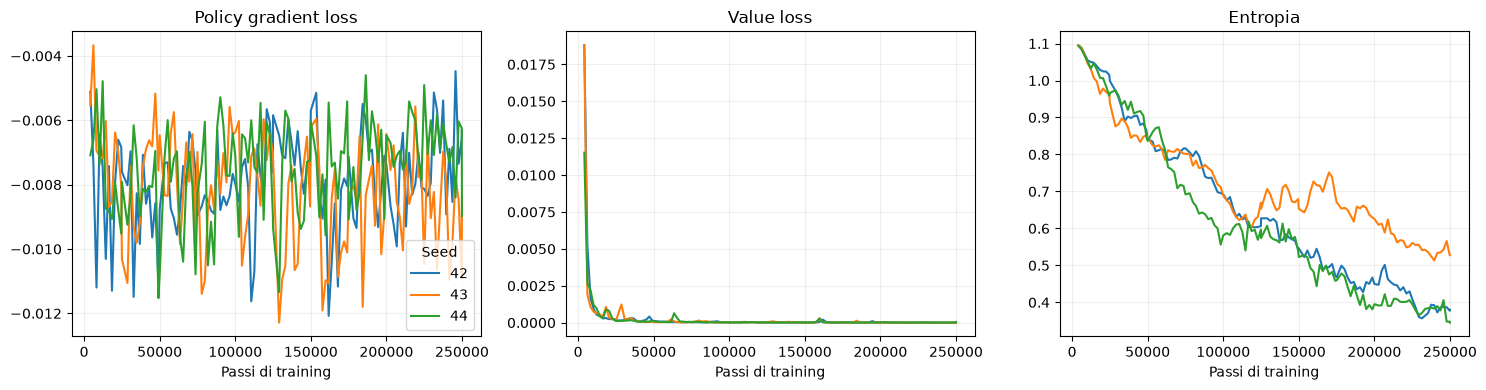

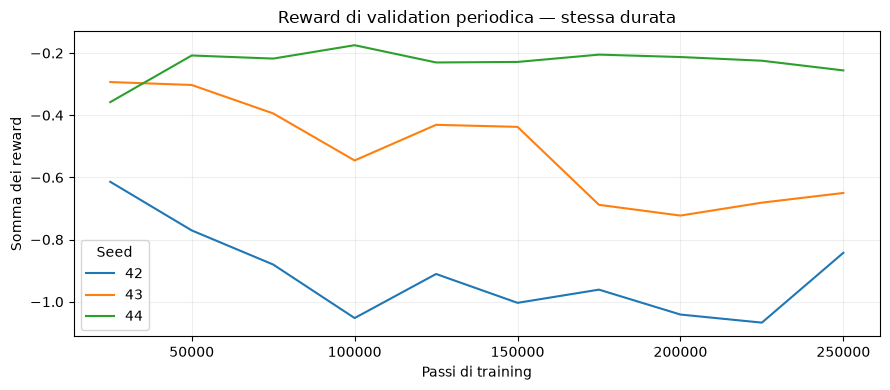

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("train/policy_gradient_loss", "Policy gradient loss", 1),
           ("train/value_loss", "Value loss", 1),
           ("train/entropy_loss", "Entropia", -1)]
for r in primary:
    log_dir = ROOT / "logs/prototype" / RUN_ID / r["label"]
    progress = pd.read_csv(log_dir / "progress.csv")
    for ax, (column, title, sign) in zip(axes, metrics):
        valid = progress[column].notna()
        values = progress.loc[valid, column]
        assert len(values) and np.isfinite(values).all()
        ax.plot(progress.loc[valid, "time/total_timesteps"], sign * values, label=str(r["seed"]))
        ax.set(title=title, xlabel="Passi di training")
        ax.grid(alpha=.2)
axes[0].legend(title="Seed")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for r in primary:
    path = ROOT / "logs/prototype" / RUN_ID / r["label"] / "eval/evaluations.npz"
    with np.load(path) as ev:
        ax.plot(ev["timesteps"], ev["results"].mean(axis=1), label=str(r["seed"]))
ax.set(title="Reward di validation periodica — stessa durata", xlabel="Passi di training", ylabel="Somma dei reward")
ax.legend(title="Seed")
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()


## Confronto omogeneo fra training e validation

La **stessa policy finale ricaricata** viene valutata deterministicamente su entrambi gli split. Si usano finestre consecutive di uguale lunghezza, portafoglio reinizializzato a ogni finestra e stessi costi. Le finestre condividono solo l'osservazione di confine, non i rendimenti. La coda incompleta viene esclusa e quantificata.

La media del reward per passo rende esplicita la durata. Il rendimento della finestra deriva dall'equity composta e non dalla somma dei reward. Le finestre appartengono a periodi di mercato diversi: il confronto descrive la generalizzazione temporale, non isola tutte le sue cause. La media degli episodi raccolti durante il training resta una diagnostica separata.


,seed,split,finestre,passi/finestra,passi esclusi,reward/passo,rendimento medio,deviazione rendimenti
0,42,train,13,5000,4758,-0.00000485,-2.39%,0.85%
1,42,validation,11,5000,4793,-0.00000971,-4.74%,0.24%
2,43,train,13,5000,4758,-0.00000428,-2.11%,0.67%
3,43,validation,11,5000,4793,-0.00000797,-3.90%,0.21%
4,44,train,13,5000,4758,-0.00000242,-1.20%,0.24%
5,44,validation,11,5000,4793,-0.00000386,-1.91%,0.22%


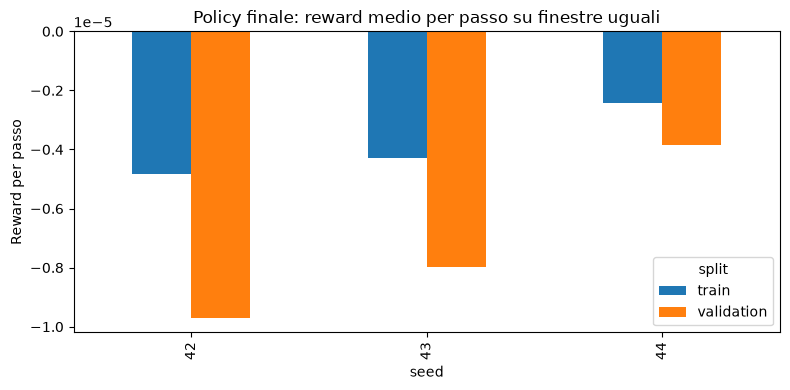

In [5]:
comparison_rows = []
for r in primary:
    for split in ["train", "validation"]:
        value = r["comparison"][split]
        comparison_rows.append({"seed": r["seed"], "split": split,
            "finestre": value["window_count"], "passi/finestra": value["window_steps"],
            "passi esclusi": value["unused_tail_steps"], "reward/passo": value["reward_per_step"],
            "rendimento medio": value["mean_window_return"], "deviazione rendimenti": value["std_window_return"]})
comparison = pd.DataFrame(comparison_rows)
display(comparison.style.format({"reward/passo": "{:.8f}", "rendimento medio": "{:.2%}", "deviazione rendimenti": "{:.2%}"}))
comparison.pivot(index="seed", columns="split", values="reward/passo").plot.bar(figsize=(8, 4))
plt.title("Policy finale: reward medio per passo su finestre uguali")
plt.ylabel("Reward per passo")
plt.tight_layout()
plt.show()


## Azioni e risultato sull'intera validation

La tabella principale usa la policy **deterministica finale**, non le azioni stocastiche campionate nel training. La soglia di degenerazione è configurabile ed effettivamente usata nei callback e nella valutazione. Una distribuzione bilanciata non garantisce scelte utili: vanno esaminati anche costi e rendimento.

Il modello `best` è scelto usando la validation e viene valutato separatamente. Il suo risultato sulla stessa validation non è una misura indipendente: un'eventuale conferma economica richiederà il test intatto.


,short,flat,long,reward,rendimento,degenere,passi
seed,,,,,,,
42,33.51%,29.48%,37.01%,-0.847665,-57.16%,False,59793
43,35.54%,29.85%,34.61%,-0.632125,-46.85%,False,59793
44,48.10%,39.99%,11.91%,-0.256580,-22.63%,False,59793


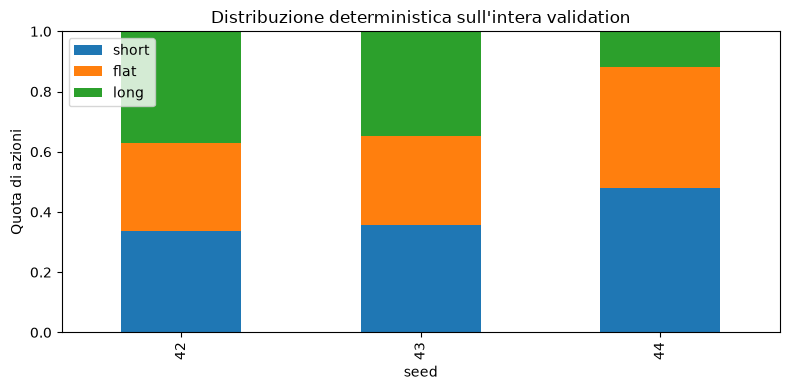

,seed,passi best,rendimento best,degenere best
0,42,25000,-0.458932,False
1,43,25000,-0.254222,False
2,44,100000,-0.160396,False


In [6]:
rows = []
for r in primary:
    v = r["validation"]
    rows.append({"seed": r["seed"], **v["action_distribution"], "reward": v["episode_reward"],
                 "rendimento": v["net_return"], "degenere": v["degenerate"], "passi": v["steps"]})
validation_table = pd.DataFrame(rows).set_index("seed")
display(validation_table.style.format({"short": "{:.2%}", "flat": "{:.2%}", "long": "{:.2%}",
                                       "rendimento": "{:.2%}", "reward": "{:.6f}"}))
validation_table[["short", "flat", "long"]].plot.bar(stacked=True, figsize=(8, 4), ylim=(0, 1))
plt.title("Distribuzione deterministica sull'intera validation")
plt.ylabel("Quota di azioni")
plt.tight_layout()
plt.show()
best_rows = [{"seed": r["seed"], "passi best": r["best_validation"]["model_timesteps"],
              "rendimento best": r["best_validation"]["net_return"],
              "degenere best": r["best_validation"]["degenerate"]} for r in primary if r["best_validation"]]
display(pd.DataFrame(best_rows))


## Riproducibilità, variabilità e conclusione

La ripetibilità della sola inferenza non dimostra quella del training. Qui il primo seed è stato riaddestrato da zero: il controllo confronta hash dei pesi, reward training, valutazione finale, confronto a finestre e numero di passi. Non confronta i byte dei file ZIP, che possono differire per metadati temporali.

La riproducibilità verificata vale per dati, sorgenti e ambiente descritti dal manifest; non promette identità tra piattaforme o versioni diverse.


In [7]:
display(pd.DataFrame([{"esecuzione": r["label"], "SHA-256 pesi policy": r["policy_sha256"]} for r in runs]))
display(pd.Series(assessment, name="Esito"))
if assessment["completion_passed"]:
    display(Markdown("**Criterio preliminare superato** secondo le tolleranze dichiarate: ripetizione identica, azioni non degeneri e variabilità multi-seed entro soglia. Questo non certifica redditività."))
else:
    failed = [name for name in ["repeat_verified", "variability_acceptable", "all_validation_runs_non_degenerate"]
              if not assessment[name]]
    display(Markdown("**Fase non ancora conclusa:** controlli non superati: " + ", ".join(failed) +
                     ". I risultati richiedono analisi; le soglie non vengono allargate dopo averli osservati."))
if all(r["validation"]["net_return"] < 0 for r in primary):
    display(Markdown("**Tutti i modelli finali perdono sulla validation.** La stabilità tecnica non è evidenza di una strategia redditizia."))


,esecuzione,SHA-256 pesi policy
0,seed_42,75ce29e2b727967de04e8160e488702810d6af0e6b8a4f...
1,seed_43,c628dd9cb5b24ec09f93068f80238b6008113b7ef8e673...
2,seed_44,a9d02cc39d71480ef88e5420feb638fae1f89a52de93f9...
3,seed_42_repeat,75ce29e2b727967de04e8160e488702810d6af0e6b8a4f...


repeat_verified                                                                    True
distinct_seeds                                                                        3
mean_window_return_range                                                       0.028243
max_action_share_range                                                         0.250966
variability_acceptable                                                            False
all_validation_runs_non_degenerate                                                 True
completion_passed                                                                 False
criteria                              {'max_mean_window_return_range': 0.1, 'max_act...
note                                  Engineering tolerances for the prototype, not ...
Name: Esito, dtype: object

**Fase non ancora conclusa:** controlli non superati: variability_acceptable. I risultati richiedono analisi; le soglie non vengono allargate dopo averli osservati.

**Tutti i modelli finali perdono sulla validation.** La stabilità tecnica non è evidenza di una strategia redditizia.

## File e ripetizione dell'esperimento

- `scripts/train_ppo.py`: subset/scaler, training, valutazioni, manifest e criterio finale.
- `src/gold_rl/rl/callbacks.py`: azioni/reward, checkpoint e valutazioni periodiche.
- `src/gold_rl/rl/persistence.py`: salvataggio compatibile con il normale `PPO.load`; `load_ppo` legge anche i vecchi archivi senza alterarli.
- `models/prototype/<run_id>/<seed>/`: modello finale e best; manifest dell'esperimento al livello superiore.
- `logs/prototype/<run_id>/<seed>/`: CSV, TensorBoard, azioni, checkpoint e valutazioni.
- `reports/ppo_prototype/<run_id>/`: manifest, riepilogo e risultati dettagliati per seed.

Per un nuovo esperimento completo:

```text
python scripts/train_ppo.py --run-id nuovo_esperimento --workers 4
```

Le directory esistenti non vengono sovrascritte. `--workers 1` esegue gli stessi lavori in sequenza. `--skip-repeat` è riservato alla diagnostica e non può certificare il completamento. Per un budget diverso usare `--timesteps`; la configurazione effettiva è registrata nel manifest. Cambiare `RUN_ID` nella prima cella per leggere un altro esperimento completato.

Controlli automatici: `python -m pytest -q`. I test dedicati verificano assenza di contaminazione dello scaler, caricamento dei pesi e dell'ottimizzatore, checkpoint, soglia delle azioni, confronto su finestre uguali, ripetizione effettiva e protezione dalle sovrascritture.
